In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pickle

with open('data/processed/tree_models_data.pkl', 'rb') as f:
    tree_data = pickle.load(f)
    
with open('data/processed/nn_models_data.pkl', 'rb') as f:
    nn_data = pickle.load(f)

tree_results   = tree_data['tree_results']
nn_results     = nn_data['nn_results']
nn_test_acc    = nn_data['nn_test_acc']
nn_tuning_time = nn_data['nn_tuning_time']

#### Final comparison

In [3]:
comparison_data = {
    'Model': ['Neural Network', 'Decision Tree', 'Random Forest', 'AdaBoost', 'Gradient Boosting'],
    'Test Accuracy': [nn_test_acc,  # This will be from your NN code
                     tree_results['Decision Tree']['test_accuracy'],
                     tree_results['Random Forest']['test_accuracy'],
                     tree_results['AdaBoost']['test_accuracy'],
                     tree_results['Gradient Boosting']['test_accuracy']],
    'Tuning Time (sec)': [nn_tuning_time,  # This will be from your NN code
                         tree_results['Decision Tree']['tuning_time_sec'],
                         tree_results['Random Forest']['tuning_time_sec'],
                         tree_results['AdaBoost']['tuning_time_sec'],
                         tree_results['Gradient Boosting']['tuning_time_sec']]
}

# Create a DataFrame for better display
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)

               Model  Test Accuracy  Tuning Time (sec)
0     Neural Network       0.850531         280.141812
1      Decision Tree       0.853652           0.389332
2      Random Forest       0.857769           3.318541
3           AdaBoost       0.853718           7.472301
4  Gradient Boosting       0.870717          13.701972


#### Comparing all models with bar chart

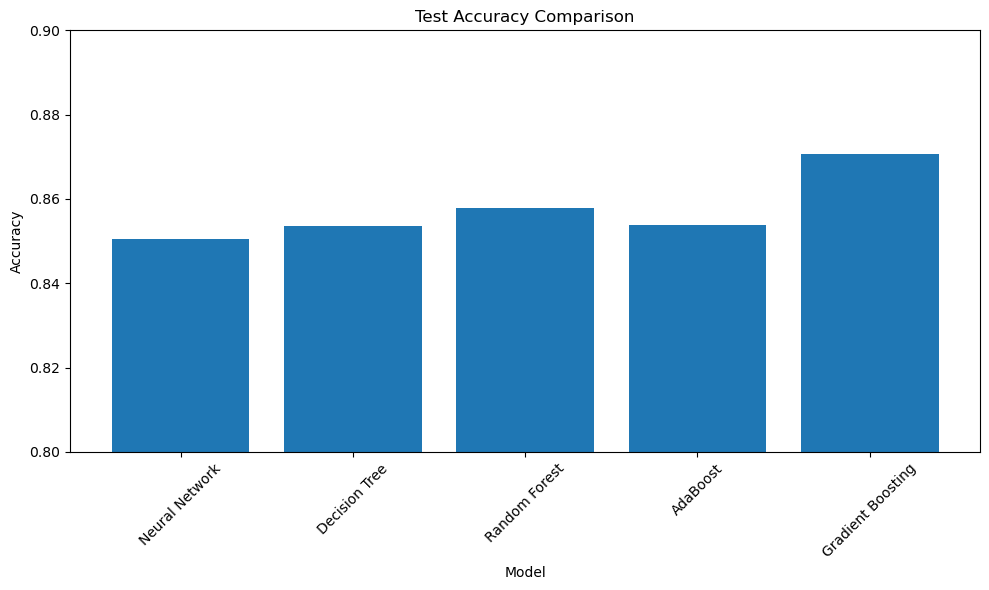

In [4]:
plt.figure(figsize=(10, 6))
plt.bar(comparison_df['Model'], comparison_df['Test Accuracy'])
plt.title('Test Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.8, 0.9)  # Adjust to make differences visible
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('model_accuracy_comparison.png')
plt.show()